In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. 基礎設定 ---
# 定義 Q1~Q4 對應的固定顏色
qubit_colors = {
    "Q1": '#9bbf8a',
    "Q2": '#92afda',
    "Q3": '#f79059',
    "Q4": '#c82423'
}

temperatures = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 157, 165, 172, 175, 183, 193]
qubits_to_plot = ["Q1", "Q2", "Q3", "Q4"]
# qubits_to_plot = ["Q1",  "Q3", "Q4"]
qubit_frequency = [3620.63506, 4029.170438, 3127.600198, 3311.82327] # MHz
all_data = []


成功讀取: qubit_results_10mK.csv
成功讀取: qubit_results_20mK.csv
成功讀取: qubit_results_30mK.csv
成功讀取: qubit_results_40mK.csv
成功讀取: qubit_results_50mK.csv
成功讀取: qubit_results_60mK.csv
成功讀取: qubit_results_70mK.csv
成功讀取: qubit_results_80mK.csv
成功讀取: qubit_results_90mK.csv
成功讀取: qubit_results_100mK.csv
成功讀取: qubit_results_110mK.csv
成功讀取: qubit_results_120mK.csv
成功讀取: qubit_results_130mK.csv
成功讀取: qubit_results_140mK.csv
成功讀取: qubit_results_157mK.csv
成功讀取: qubit_results_165mK.csv
成功讀取: qubit_results_172mK.csv
成功讀取: qubit_results_175mK.csv
成功讀取: qubit_results_183mK.csv
成功讀取: qubit_results_193mK.csv


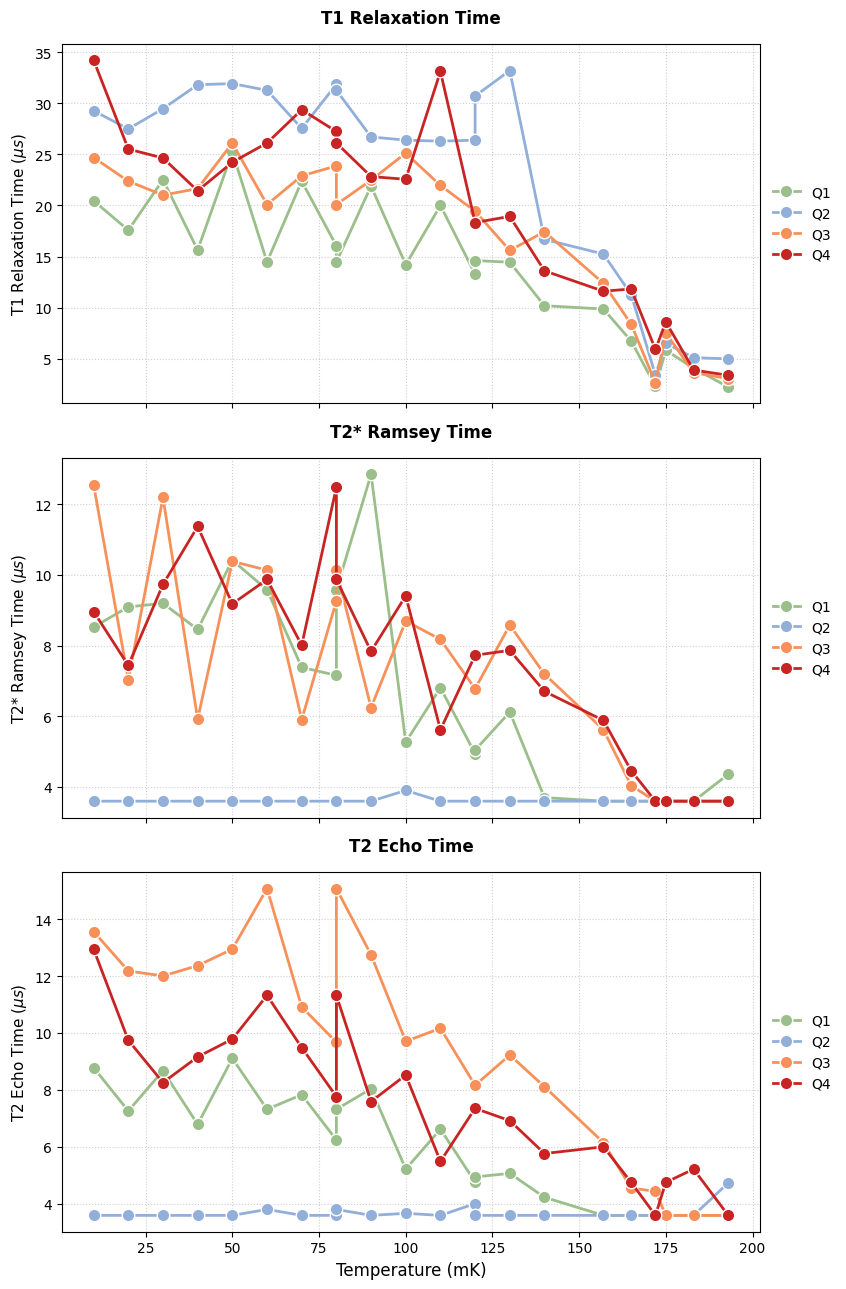

In [6]:

# --- 2. 讀取數據 ---
for temp in temperatures:
    file_path = f"qubit_results_{temp}mK.csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if not df.empty:
            all_data.append(df)
            print(f"成功讀取: {file_path}")
    else:
        print(f"找不到檔案: {file_path}")

if len(all_data) == 0:
    print("❌ 錯誤：沒有讀取到任何數據！")
else:
    df_total = pd.concat(all_data, ignore_index=True)

    # --- 3. 開始繪圖 ---
    # 定義子圖指標 (欄位名, 誤差欄位名, 顯示標題)
    metrics = [
        ('t1_time', 't1_err', 'T1 Relaxation Time'),
        ('t2r_time', 't2r_err', 'T2* Ramsey Time'),
        ('t2e_time', 't2e_err', 'T2 Echo Time')
    ]

    fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 13), sharex=True)

    for i, (val_col, err_col, title) in enumerate(metrics):
        ax = axes[i]
        
        for q in qubits_to_plot:
            # 挑選資料
            q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
            if q_df.empty:
                continue

            # 取得該 Qubit 專屬顏色
            q_color = qubit_colors.get(q, '#000000') # 預設黑色
            
            # 轉換數據格式
            temp_x = q_df['temp_mK'].values
            y_vals = pd.to_numeric(q_df[val_col], errors='coerce').values
            y_errs = pd.to_numeric(q_df[err_col], errors='coerce').fillna(0).values
            
            # 畫出 Qubit 的中心線與點
            ax.plot(temp_x, y_vals, 'o-', label=f'{q}', color=q_color, 
                    markersize=9, linewidth=2, markeredgecolor='white', markeredgewidth=1)
            
            # 畫出 Qubit 的 Error Band (誤差帶)
            # ax.fill_between(temp_x, y_vals - y_errs, y_vals + y_errs, 
            #                 color=q_color, alpha=0.2)

        # 子圖美化
        ax.set_ylabel(f"{title} ($\mu s$)", fontsize=11)
        ax.set_title(title, fontweight='bold', pad=15)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False) # 標籤放在右側

    axes[-1].set_xlabel("Temperature (mK)", fontsize=12)
    
    # 調整間距以容納右側 Legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.85) 
    plt.show()

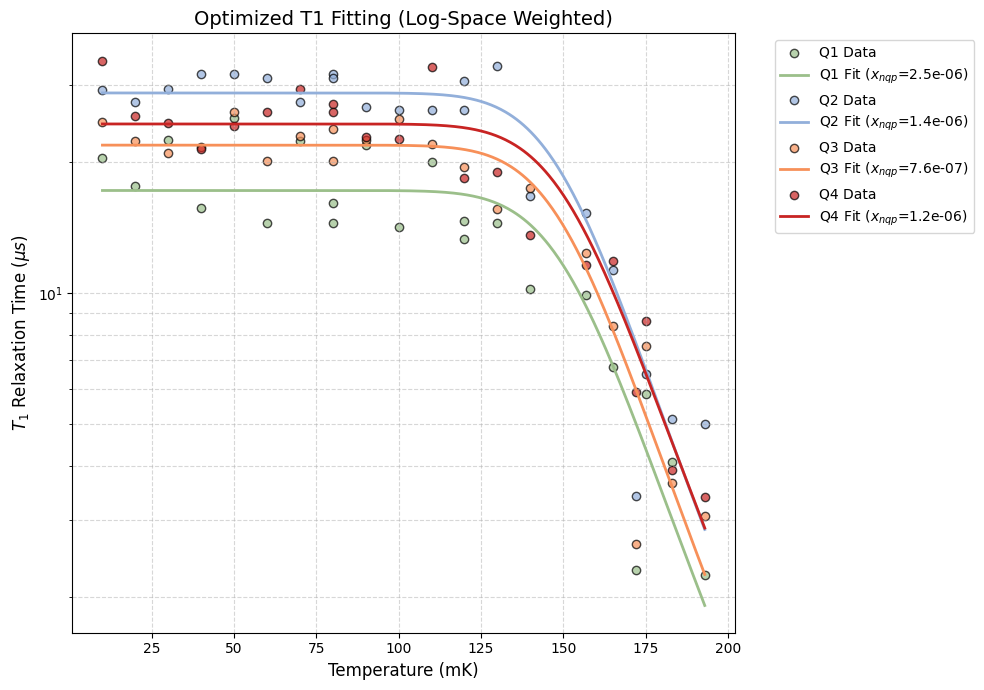

[Q1 Fit Results]
  Optimized x_nqp : 1.21e-06
  Current n_qp   : 7.4827 μm⁻³
  T1 Limit (T->0): 24.5 us
  T2 Limit (T->0): 22.5 us
----------------------------------------
[Q2 Fit Results]
  Optimized x_nqp : 1.21e-06
  Current n_qp   : 7.4827 μm⁻³
  T1 Limit (T->0): 24.5 us
  T2 Limit (T->0): 21.3 us
----------------------------------------
[Q3 Fit Results]
  Optimized x_nqp : 1.21e-06
  Current n_qp   : 7.4827 μm⁻³
  T1 Limit (T->0): 24.5 us
  T2 Limit (T->0): 24.1 us
----------------------------------------
[Q4 Fit Results]
  Optimized x_nqp : 1.21e-06
  Current n_qp   : 7.4827 μm⁻³
  T1 Limit (T->0): 24.5 us
  T2 Limit (T->0): 23.4 us
----------------------------------------


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. 物理常數 ---
qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8} 
EC = 200 
DELTA_KB = 1800 
DELTA_UEV = 180 

def qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    # 增加 epsilon 防止 T=0 報錯
    T = np.maximum(T, 1e-6)
    term_sqrt = np.sqrt(2 * np.pi * T / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / T)
    x_qp = x_nqp + term_sqrt * term_exp
    return Gamma_bg + scale_factor * x_qp


def log_qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    return np.log10(qp_rate_model(T, Gamma_bg, scale_factor, x_nqp))

# --- 2. 核心分析與繪圖 ---
plt.figure(figsize=(10, 7))

for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_data = q_df['temp_mK'].values
    T1_data = q_df['t1_time'].values
    rate_data = 1 / T1_data
    log_rate_data = np.log10(rate_data)
    
    try:
        # 優化點 1: 更精確的初始猜測
        # Gamma_bg 猜測最低溫度的速率
        g_bg_init = rate_data.min()
        # scale_factor 理論值大約在 10^2 ~ 10^3 之間
        
        # 優化點 2: 使用對數擬合以提高低溫段準確度
        popt, _ = curve_fit(log_qp_rate_model, T_data, log_rate_data, 
                            p0=[g_bg_init, 800, 1e-7], 
                            bounds=([0, 1, 1e-10], [1, 1e5, 1e-4]),
                            maxfev=10000)
        
        g_bg, s_fit, x_nqp_fit = popt
        
        # 繪圖
        plt.scatter(T_data, T1_data, color=qubit_colors[q], label=f'{q} Data', alpha=0.7, edgecolors='k')
        T_fit = np.linspace(T_data.min(), T_data.max(), 500)
        rate_fit = qp_rate_model(T_fit, *popt)
        plt.plot(T_fit, 1/rate_fit, '-', color=qubit_colors[q], linewidth=2,
                 label=f'{q} Fit ($x_{{nqp}}$={x_nqp_fit:.1e})')
        
        # --- 計算 T2 Limit ---
        f_ge = qubit_freqs[q]
        wp = f_ge + EC
        t1_limit = 1 / qp_rate_model(1e-6, *popt) # 近似 T=0
        gamma_phi_nqp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_nqp_fit
        rate_t2_limit = (1 / (2 * t1_limit)) + (2 * np.pi * gamma_phi_nqp)
        t2_limit = 1 / rate_t2_limit
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")

plt.yscale('log')
plt.xlabel("Temperature (mK)", fontsize=12)
plt.ylabel("$T_1$ Relaxation Time ($\mu s$)", fontsize=12)
plt.title("Optimized T1 Fitting (Log-Space Weighted)", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



N0_AL = 1.72e10   # 1/eV/um^3
DELTA_EV = 180e-6 # 180 ueV 轉為 eV

for q in ["Q1", "Q2", "Q3", "Q4"]:
    try:
        g_bg, s_fit, x_nqp_fit = popt
        n_qp_current = 2 * N0_AL * DELTA_EV * x_nqp_fit
        # --- 計算 T2 Limit ---
        f_ge = qubit_freqs[q]
        wp = f_ge + EC
        t1_limit = 1 / qp_rate_model(1e-6, *popt) 
        gamma_phi_nqp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_nqp_fit
        rate_t2_limit = (1 / (2 * t1_limit)) + (2 * np.pi * gamma_phi_nqp)
        t2_limit = 1 / rate_t2_limit

        print(f"[{q} Fit Results]")
        print(f"  Optimized x_nqp : {x_nqp_fit:.2e}")
        print(f"  Current n_qp   : {n_qp_current:.4f} μm⁻³") # <-- 新增這行
        print(f"  T1 Limit (T->0): {t1_limit:.1f} us")
        print(f"  T2 Limit (T->0): {t2_limit:.1f} us")
        print("-" * 40)
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")


In [ ]:
print("\n" + "="*50)
print("Manual Prediction")
print("="*50)

# from https://arxiv.org/pdf/2309.02655
# x_nqp = 8e-8
# from Minimizing quasiparticle generation from stray infrared lightin superconducting quantum circuits
# after optimization radiation n_qp = 0.2 μm⁻³

manual_x_nqp =0.51e-8    
manual_temp = 30        
target_q = "Q1"          


N0_AL = 1.72e10   # 1/eV/um^3
DELTA_EV = 180e-6 # 180 ueV 轉為 eV
manual_n_qp_current = 2 * N0_AL * DELTA_EV * manual_x_nqp




if target_q in qubit_freqs:
    f_ge = qubit_freqs[target_q]
    wp = f_ge + EC
    

    term_sqrt = np.sqrt(2 * np.pi * manual_temp / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / manual_temp)
    x_qp_at_T = manual_x_nqp + term_sqrt * term_exp

    current_s_fit = s_fit 
    current_g_bg = g_bg 


    rate_t1 =  current_s_fit * x_qp_at_T + current_g_bg
    t1_pred = 1 / rate_t1
    
    # 計算 T2 (包含 Pure Dephasing)
    # gamma_phi_qp 單位為 MHz
    gamma_phi_qp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_qp_at_T
    rate_t2 = (1 / (2 * t1_pred)) + (2 * np.pi * gamma_phi_qp)
    t2_pred = 1 / rate_t2
    
    print(f"輸入參數:")
    print(f"  Qubit: {target_q} (fge={f_ge} MHz, Ec={EC} MHz)")
    print(f"  手動 x_nqp: {manual_x_nqp:.2e}")
    print(f"  目標溫度: {manual_temp} mK")
    print("-" * 20)
    print(f"計算結果:")
    print(f"  target x_qp : {x_qp_at_T:.2e}")
    print(f"  manual n_qp   : {manual_n_qp_current:.4f} μm⁻³")
    print(f"  predic T1          : {t1_pred:.2f} us")
    print(f"  predic T2          : {t2_pred:.2f} us")
    print(f"  Pure Dephasing : {2 * np.pi * gamma_phi_qp * 1000:.2f} kHz")


Manual Prediction
輸入參數:
  Qubit: Q4 (fge=3311.8 MHz, Ec=200 MHz)
  手動 x_nqp: 5.10e-09
  目標溫度: 30 mK
--------------------
計算結果:
  target x_qp : 5.10e-09
  manual n_qp   : 0.0316 μm⁻³
  predic T1          : 27.90 us
  predic T2          : 55.51 us
  Pure Dephasing : 0.09 kHz
